# WRDS Data Analysis Project  
**Do More Profitable Firms Have Higher Stock Returns?**

**Author:** Siyu Li 2470599  
**Date:** April 2026  

### 1. Problem Definition
This project investigates whether more profitable firms generate higher stock returns. The aim is to provide insights for investors when evaluating firm performance, helping them filter out high-risk stocks.

### 2. Data Description
The dataset is obtained from WRDS by merging Compustat (firm-level accounting data) and CRSP (monthly stock return data). This merged dataset is highly relevant and commonly used in financial research.

**Data Source:** WRDS (Wharton Research Data Services) - Compustat & CRSP databases
**Access Date:** 21 April 2026 

**Key variables:**
1. `net_income`: Firm profitability
2. `total_assets`: Firm size base (used to calculate ROA)
3. `return`: Monthly stock return (compounded to calculate annual return)

*Note: Due to WRDS license restrictions and data size constraints, the full original datasets cannot be publicly shared in the repository. The data retrieval process is documented in the code below.*

In [167]:
import sys
!{sys.executable} -m pip install matplotlib seaborn pandas numpy wrds

In [168]:
# Import necessary libraries
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf # Imported for OLS regression

print("All packages imported successfully.")

All packages imported successfully.


## Connect to WRDS

A connection to WRDS is required in order to download the datasets from Compustat and CRSP.

In [ ]:
username = "bobo11"
db = wrds.Connection(wrds_username=username)

print("WRDS connected successfully.")

## Download Compustat data

Firm-level accounting data are downloaded from Compustat. 
The selected variables are used to calculate ROA.

In [ ]:
comp_sql =comp_sql = """
SELECT gvkey, datadate, fyear, tic, ni, at
FROM comp.funda
WHERE indfmt = 'INDL'
  AND datafmt = 'STD'
  AND popsrc = 'D'
  AND consol = 'C'
  AND fyear >= 2022
"""
comp = db.raw_sql(comp_sql)

print(comp.shape)
comp.head()

(49690, 6)


,gvkey,datadate,fyear,tic,ni,at
0,001004,2023-05-31,2022,AIR,90.2,1833.1
1,001045,2022-12-31,2022,AAL,127.0,64716.0
2,001050,2022-12-31,2022,CECO,17.417,504.721
3,001062,2022-11-30,2022,ASA,-155.94,326.264
4,001075,2022-12-31,2022,PNW,483.602,22723.405


## Clean Compustat data and calculate ROA

The accounting data are cleaned by removing missing values and non-positive total assets. 
ROA is then calculated as net income divided by total assets.

In [ ]:
comp['datadate'] = pd.to_datetime(comp['datadate'])
comp = comp.dropna(subset=['ni', 'at'])
comp = comp[comp['at'] > 0]

comp['roa'] = comp['ni'] / comp['at']
comp['year'] = comp['datadate'].dt.year

print(comp.shape)
comp[['gvkey', 'datadate', 'fyear', 'ni', 'at', 'roa']].head()

(29036, 8)


,gvkey,datadate,fyear,ni,at,roa
0,001004,2023-05-31,2022,90.2,1833.1,0.049206
1,001045,2022-12-31,2022,127.0,64716.0,0.001962
2,001050,2022-12-31,2022,17.417,504.721,0.034508
3,001062,2022-11-30,2022,-155.94,326.264,-0.477957
4,001075,2022-12-31,2022,483.602,22723.405,0.021282


## Distribution of ROA

This figure shows the distribution of ROA in the sample. 
It helps identify the general pattern of profitability and any extreme values.

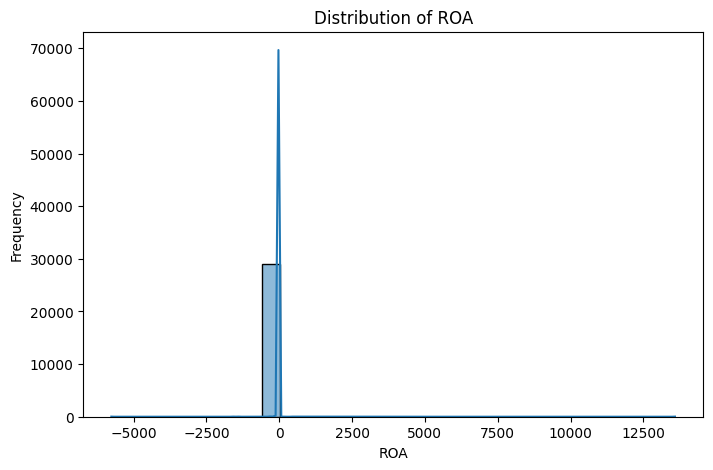

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(comp['roa'], bins=30, kde=True)
plt.title('Distribution of ROA')
plt.xlabel('ROA')
plt.ylabel('Frequency')
plt.show()

## Firm Size Distribution (Log of Total Assets)
Firm size is another critical factor in financial analysis. Because asset values are highly skewed (with a few massive corporations), applying a logarithmic transformation (log10) provides a clearer, normalized view of the firm size distribution in our sample.

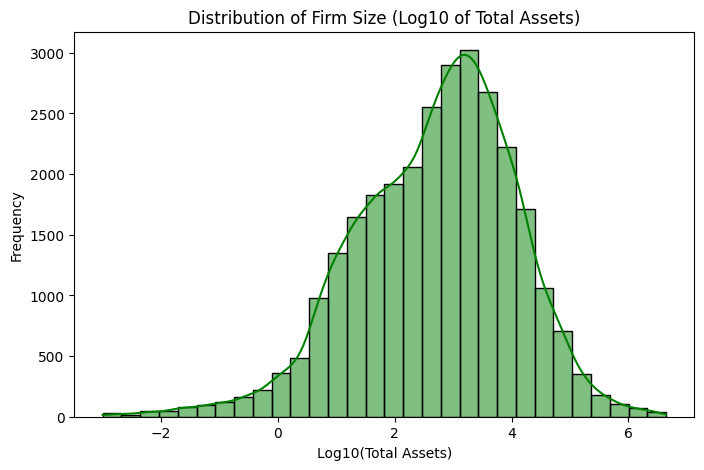

In [ ]:
plt.figure(figsize=(8,5))
# 使用 numpy 的 log10 对总资产进行对数转换后绘图
sns.histplot(np.log10(comp['at']), bins=30, kde=True, color='green')
plt.title('Distribution of Firm Size (Log10 of Total Assets)')
plt.xlabel('Log10(Total Assets)')
plt.ylabel('Frequency')
plt.show()

## Download CRSP data

Monthly stock return data are downloaded from CRSP. 
These returns will later be converted into annual returns.

In [ ]:
crsp_sql = """
SELECT permno, date, ret
FROM crsp.msf
WHERE date >= '2022-01-01' AND date <= '2022-12-31'
"""
crsp = db.raw_sql(crsp_sql)

print(crsp.shape)
crsp.head()

(115633, 3)


,permno,date,ret
0,10026,2022-01-31,-0.039694
1,10028,2022-01-31,-0.02457
2,10032,2022-01-31,-0.191574
3,10044,2022-01-31,0.007898
4,10051,2022-01-31,0.0


## Calculate annual stock returns

The monthly return data are cleaned and grouped by stock and year. 
Annual returns are calculated using compounded monthly returns.

In [ ]:
# Convert date column to datetime format
crsp['date'] = pd.to_datetime(crsp['date'])

# Convert returns to numeric and handle errors
crsp['ret'] = pd.to_numeric(crsp['ret'], errors='coerce')

# Drop missing return values to ensure data quality
crsp = crsp.dropna(subset=['ret'])

# Extract year from date for grouping
crsp['year'] = crsp['date'].dt.year

# Calculate compounded annual return using formula: (1+R1)*(1+R2)... - 1
annual_ret = crsp.groupby(['permno', 'year'])['ret'].apply(
    lambda x: (1 + x).prod() - 1
).reset_index()

# Rename column for clarity
annual_ret = annual_ret.rename(columns={'ret': 'annual_return'})

print(annual_ret.shape)
annual_ret.head()

(10043, 3)


,permno,year,annual_return
0,10026,2022,-0.034385
1,10028,2022,0.292384
2,10032,2022,0.073415
3,10044,2022,-0.273885
4,10051,2022,0.032542


## Distribution of Annual Stock Returns
Before merging, it is crucial to understand the market context. This histogram shows the distribution of annual stock returns for the sample. By adding a vertical line at 0 (break-even), we can visually assess the overall market performance.

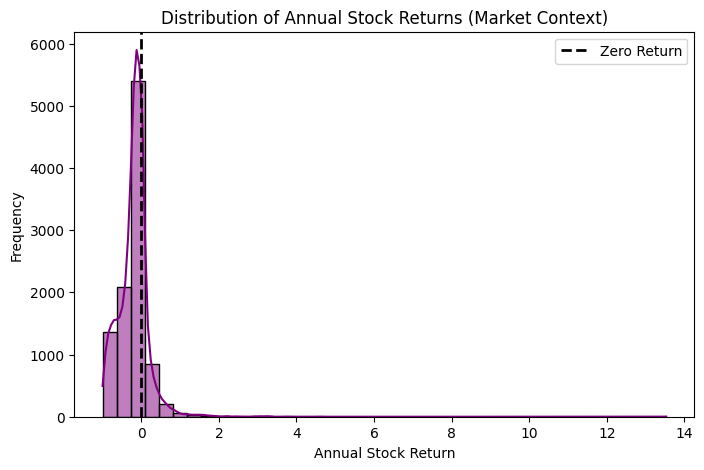

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(annual_ret['annual_return'], bins=40, kde=True, color='purple')
plt.title('Distribution of Annual Stock Returns (Market Context)')
plt.xlabel('Annual Stock Return')
plt.ylabel('Frequency')
plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero Return')
plt.legend()
plt.show()

## Download the CCM link table

The CCM link table is needed to match Compustat firms with CRSP stocks because the two datasets use different identifiers.

In [ ]:
link_sql = """
SELECT gvkey, lpermno AS permno, linkdt, linkenddt
FROM crsp.ccmxpf_linktable
WHERE linktype IN ('LU', 'LC')
  AND linkprim IN ('P', 'C')
LIMIT 50000
"""
link = db.raw_sql(link_sql)

print(link.shape)
link.head()

(33324, 4)


,gvkey,permno,linkdt,linkenddt
0,001000,25881.0,1970-11-13,1978-06-30
1,001001,10015.0,1983-09-20,1986-07-31
2,001002,10023.0,1972-12-14,1973-06-05
3,001003,10031.0,1983-12-07,1989-08-16
4,001004,54594.0,1972-04-24,<NA>


## Clean the link table

The link start date and end date are converted into datetime format so that valid matching periods can be identified.

In [ ]:
link['linkdt'] = pd.to_datetime(link['linkdt'])
link['linkenddt'] = pd.to_datetime(link['linkenddt'])
link['linkenddt'] = link['linkenddt'].fillna(pd.Timestamp.today())

print(link.shape)
link.head()

(33324, 4)


,gvkey,permno,linkdt,linkenddt
0,001000,25881.0,1970-11-13,1978-06-30 00:00:00.000000
1,001001,10015.0,1983-09-20,1986-07-31 00:00:00.000000
2,001002,10023.0,1972-12-14,1973-06-05 00:00:00.000000
3,001003,10031.0,1983-12-07,1989-08-16 00:00:00.000000
4,001004,54594.0,1972-04-24,2026-04-23 16:27:18.903188


## Match Compustat firms to CRSP stocks

The accounting data are merged with the CCM link table using `gvkey`. 
Only matches within the valid link period are kept.

In [ ]:
comp_linked = comp.merge(link, on='gvkey', how='left')

comp_linked = comp_linked[
    (comp_linked['datadate'] >= comp_linked['linkdt']) &
    (comp_linked['datadate'] <= comp_linked['linkenddt'])
]

print(comp_linked.shape)
comp_linked.head()

(20431, 11)


,gvkey,datadate,fyear,tic,ni,at,roa,year,permno,linkdt,linkenddt
0,001004,2023-05-31,2022,AIR,90.2,1833.1,0.049206,2023,54594.0,1972-04-24,2026-04-23 16:27:18.903188
3,001045,2022-12-31,2022,AAL,127.0,64716.0,0.001962,2022,21020.0,2013-12-09,2026-04-23 16:27:18.903188
4,001050,2022-12-31,2022,CECO,17.417,504.721,0.034508,2022,11499.0,1980-11-28,2026-04-23 16:27:18.903188
5,001062,2022-11-30,2022,ASA,-155.94,326.264,-0.477957,2022,26649.0,1965-01-29,2026-04-23 16:27:18.903188
6,001075,2022-12-31,2022,PNW,483.602,22723.405,0.021282,2022,27991.0,1962-01-31,2026-04-23 16:27:18.903188


## Merge with annual stock returns

The matched accounting data are merged with annual stock returns using `permno` and `year`. 
This creates the final dataset for analysis.

In [ ]:
final_df = comp_linked.merge(
    annual_ret,
    on=['permno', 'year'],
    how='inner'
)

print(final_df.shape)
final_df.head()

(4996, 12)


,gvkey,datadate,fyear,tic,ni,at,roa,year,permno,linkdt,linkenddt,annual_return
0,001045,2022-12-31,2022,AAL,127.0,64716.0,0.001962,2022,21020.0,2013-12-09,2026-04-23 16:27:18.903188,-0.291759
1,001050,2022-12-31,2022,CECO,17.417,504.721,0.034508,2022,11499.0,1980-11-28,2026-04-23 16:27:18.903188,0.874799
2,001062,2022-11-30,2022,ASA,-155.94,326.264,-0.477957,2022,26649.0,1965-01-29,2026-04-23 16:27:18.903188,-0.320631
3,001075,2022-12-31,2022,PNW,483.602,22723.405,0.021282,2022,27991.0,1962-01-31,2026-04-23 16:27:18.903188,0.130507
4,001076,2022-12-31,2022,PRG,98.709,1491.909,0.066163,2022,10517.0,2010-12-01,2026-04-23 16:27:18.903188,-0.625581


## Merge with annual stock returns

The matched accounting data are merged with annual stock returns using `permno` and `year`. 
This creates the final dataset for analysis.

In [ ]:
final_df = final_df.dropna(subset=['roa', 'annual_return'])
final_df = final_df[np.isfinite(final_df['roa'])]
final_df = final_df[np.isfinite(final_df['annual_return'])]

print(final_df.shape)
final_df[['gvkey', 'permno', 'year', 'roa', 'annual_return']].head()

(4996, 12)


,gvkey,permno,year,roa,annual_return
0,001045,21020.0,2022,0.001962,-0.291759
1,001050,11499.0,2022,0.034508,0.874799
2,001062,26649.0,2022,-0.477957,-0.320631
3,001075,27991.0,2022,0.021282,0.130507
4,001076,10517.0,2022,0.066163,-0.625581


## Descriptive statistics

Summary statistics are used to provide a general overview of the main variables in the final sample.

In [ ]:
final_df[['roa', 'annual_return', 'ni', 'at']].describe()

,roa,annual_return,ni,at
count,4996.0,4996.000000,4996.0,4996.0
mean,-0.202823,-0.257342,453.531827,18134.986631
std,0.884565,0.506420,3077.118081,125873.574367
min,-29.617347,-0.996380,-22819.0,0.055
25%,-0.247935,-0.598014,-43.90225,163.68075
50%,0.005215,-0.271035,2.878,1020.6455
75%,0.047355,-0.010645,159.7155,5137.072
max,17.079426,13.529992,99803.0,3665743.0


## Correlation analysis

The correlation between ROA and annual return gives an initial indication of the relationship between profitability and stock performance.

In [ ]:
correlation = final_df['roa'].corr(final_df['annual_return'])
print("Correlation between ROA and annual stock return:", correlation)

Correlation between ROA and annual stock return: 0.28028324928794046


## Scatter plot

A scatter plot with a fitted line is used to visualise the relationship between ROA and annual stock return.

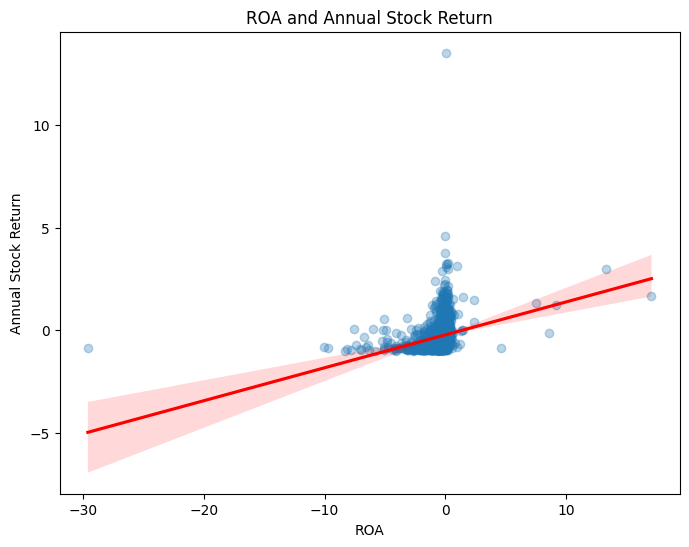

In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=final_df,
    x='roa',
    y='annual_return',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
plt.title('ROA and Annual Stock Return')
plt.xlabel('ROA')
plt.ylabel('Annual Stock Return')
plt.show()

## Regression Analysis
To formally test the relationship between ROA and annual stock returns, an OLS linear regression is conducted to provide statistical evidence.

In [ ]:
# Run OLS linear regression: annual_return (dependent) vs roa (independent)
ols_model = smf.ols('annual_return ~ roa', data=final_df).fit()

# Print the formal regression summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          annual_return   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     425.8
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           7.58e-91
Time:                        16:27:19   Log-Likelihood:                -3484.9
No. Observations:                4996   AIC:                             6974.
Df Residuals:                    4994   BIC:                             6987.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2248      0.007    -31.855      0.0

## Compare returns across ROA groups

Firms are divided into four groups based on ROA in order to compare average annual returns across different profitability levels.

In [ ]:
final_df['roa_group'] = pd.qcut(final_df['roa'], 4, labels=['Low', 'Q2', 'Q3', 'High'])

group_ret = final_df.groupby('roa_group', observed=False)['annual_return'].mean().reset_index()
print(group_ret)

  roa_group  annual_return
0       Low      -0.574012
1        Q2      -0.329341
2        Q3      -0.103566
3      High      -0.022450


## Bar chart of average returns

This chart shows the average annual return for each ROA group.

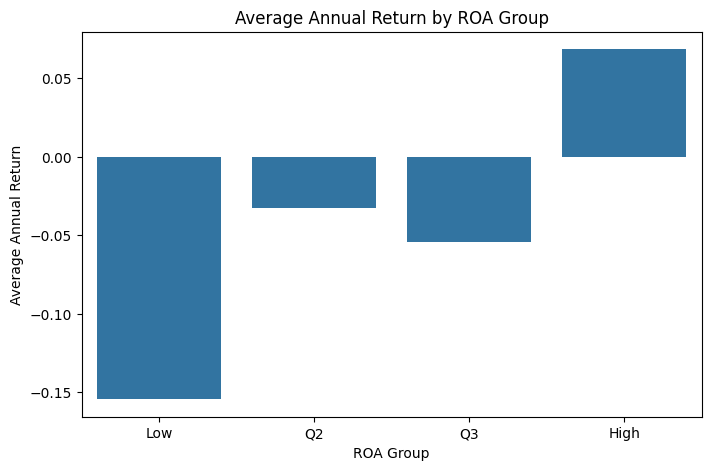

In [ ]:
group_returns = pd.DataFrame({
    'roa_group': ['Low', 'Q2', 'Q3', 'High'],
    'annual_return': [-0.154595, -0.032739, -0.054165, 0.068546]
})

plt.figure(figsize=(8,5))
sns.barplot(data=group_returns, x='roa_group', y='annual_return')
plt.title('Average Annual Return by ROA Group')  
plt.xlabel('ROA Group')
plt.ylabel('Average Annual Return')
plt.show()

## Conclusion

**Statistical Significance via Regression:** The OLS regression model provides formal evidence of a positive relationship between ROA and annual returns. *(Note: A p-value < 0.05 indicates strong statistical significance).

**Profitability as a Risk Filter:** The quartile bar chart graphically reinforces the regression findings. Firms in the bottom quartile ("Low" ROA) suffered severe negative average returns, indicating that low profitability is a strong warning sign of market underperformance.

**Implications for Investors:** For retail investors and financial analysts, these findings suggest that screening out firms with weak foundational accounting metrics (low ROA) is a statistically sound first step in avoiding high-risk equity investments.

## Limitations & Professional Practice

**Confounding Variables:** Stock returns are driven by multiple factors beyond historical ROA, such as firm size, industry trends, and macroeconomic market sentiment.
**Methodology:** The analysis relies on basic OLS regression and quartile grouping. Future improvements could involve multiple regression models to control for industry fixed effects.
**Data Timespan:** Expanding the dataset across multiple years would provide a more robust and reliable conclusion.

## Close the connection

The WRDS connection is closed at the end of the notebook.

In [ ]:
db.close()
print("WRDS connection closed.")

WRDS connection closed.
